# Hydrology pipeline

Real-world DEM-to-streams workflow covering:

```text
DEM
  → full_hydro_pipeline   (fill → flow_direction → accumulate → streams)
  → order(method="hack")
  → order(method="topological")
  → to_vector(...) carrying sinuosity
  → main_stem(...)
  → prune_short(...)
  → hand(method="euclidean")
```

We build a synthetic mountain catchment with a confluence and exercise every stage on it.

In [1]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 80
plt.rcParams["savefig.dpi"] = 80


In [2]:
import numpy as np
from pyramids.dataset import Dataset
from digitalrivers import DEM

rows, cols = 20, 20
z = np.full((rows, cols), 100.0, dtype=np.float32)
for r in range(rows):
    z[r, 10] = float(40 - 2 * r)  # main stem descends south down col 10
for c in range(10):
    z[8, c] = float(35 - c)        # west tributary into (8, 10)
for c in range(11, cols):
    z[13, c] = float(25 - (c - 11))  # east tributary into (13, 10)

ds = Dataset.create_from_array(
    z, top_left_corner=(0.0, 0.0), cell_size=30.0, epsg=32618, no_data_value=-9999.0,
)
dem = DEM(ds.raster)
print(f"DEM shape={z.shape}  elevation range=[{z.min():.1f}, {z.max():.1f}] m")

2026-05-17 22:36:06 | INFO | pyramids.base.config | Logging is configured.


DEM shape=(20, 20)  elevation range=[2.0, 100.0] m


## Visualise the synthetic catchment

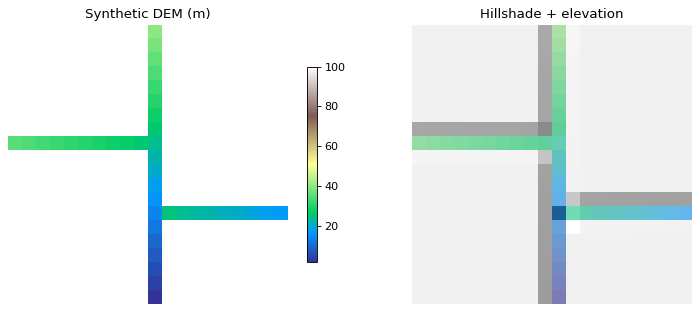

In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

elev = dem.values
ls = LightSource(azdeg=315, altdeg=45)
shade = ls.hillshade(elev, vert_exag=2.0, dx=30.0, dy=30.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(elev, cmap="terrain", origin="upper")
axes[0].set_title("Synthetic DEM (m)"); axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], shrink=0.7)

axes[1].imshow(shade, cmap="gray", origin="upper")
axes[1].imshow(elev, cmap="terrain", origin="upper", alpha=0.55)
axes[1].set_title("Hillshade + elevation"); axes[1].axis("off")
fig.tight_layout()
plt.show()


## composite hydro pipeline

`DEM.full_hydro_pipeline(...)` chains fill → flow_direction → accumulate → streams in one call and
returns a dict of typed results.

In [4]:
bundle = dem.full_hydro_pipeline(
    fill_method="priority_flood",
    flow_method="d8",
    stream_threshold_cells=4,
)
filled = bundle["filled_dem"]
fdir = bundle["flow_direction"]
acc = bundle["accumulation"]
streams = bundle["streams"]

n_stream = int(streams.read_array().astype(bool).sum())
print(f"filled_dem  type={type(filled).__name__}")
print(f"fdir        routing={fdir.routing}")
print(f"acc         max={int(acc.read_array().max())}  routing={acc.routing}")
print(f"streams     cells={n_stream}  threshold={streams.threshold}")

filled_dem  type=DEM
fdir        routing=d8
acc         max=86  routing=d8
streams     cells=35  threshold=4.0


## Visualise the hydro-pipeline outputs

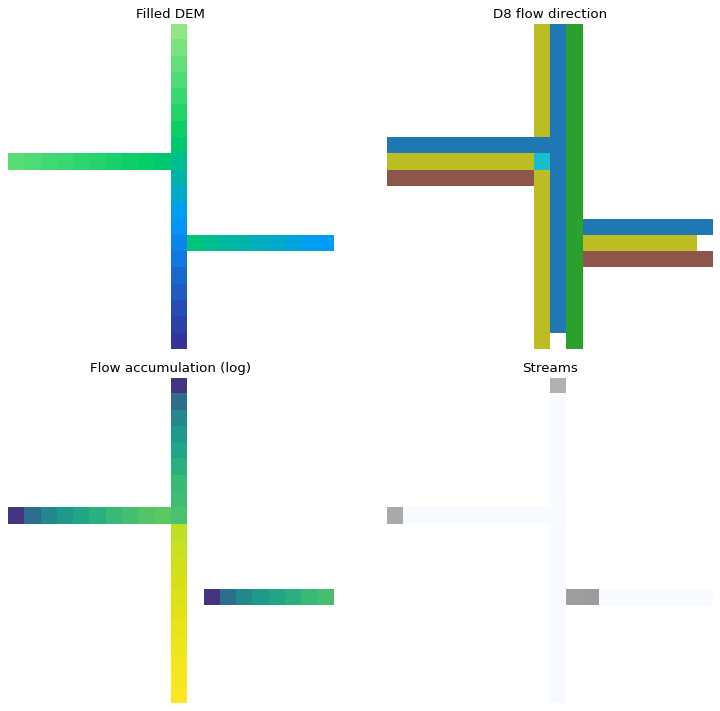

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sm = streams.read_array().astype(bool)
fd_arr = fdir.read_array()
acc_arr = acc.read_array()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes[0, 0].imshow(filled.values, cmap="terrain", origin="upper")
axes[0, 0].set_title("Filled DEM"); axes[0, 0].axis("off")

fd_show = np.where(fd_arr < 0, np.nan, fd_arr).astype(float)
axes[0, 1].imshow(fd_show, cmap="tab10", origin="upper")
axes[0, 1].set_title("D8 flow direction"); axes[0, 1].axis("off")

axes[1, 0].imshow(np.where(acc_arr < 1, np.nan, acc_arr),
                  cmap="viridis", norm=LogNorm(vmin=1, vmax=acc_arr.max()),
                  origin="upper")
axes[1, 0].set_title("Flow accumulation (log)"); axes[1, 0].axis("off")

axes[1, 1].imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
axes[1, 1].imshow(np.where(sm, 1, np.nan), cmap="Blues", origin="upper")
axes[1, 1].set_title("Streams"); axes[1, 1].axis("off")
fig.tight_layout()
plt.show()


## Hack stream ordering

Order 1 is assigned to the main stem (longest source-to-outlet path). Every tributary joining the
main stem becomes order 2; tributaries of those order 3; and so on.

In [6]:
hack = streams.order(method="hack", flow_direction=fdir)
hack_arr = hack.read_array()
sm = streams.read_array().astype(bool)
print(f"Hack orders on stream cells: {sorted(set(int(v) for v in hack_arr[sm]))}")
print(f"Order-1 (main stem) cells: {int((hack_arr == 1).sum())}")
print(f"Order-2 (1st tributary) cells: {int((hack_arr == 2).sum())}")

Hack orders on stream cells: [1, 2]
Order-1 (main stem) cells: 27
Order-2 (1st tributary) cells: 8


## Topological stream ordering

Kahn-sort sequential numbering. Heads are enumerated in row-major order first, then progressively
downstream. The outlet's index equals the total stream-cell count.

In [7]:
topo = streams.order(method="topological", flow_direction=fdir)
topo_arr = topo.read_array()
print(f"Topological max (outlet index): {int(topo_arr.max())}")
print(f"Stream cell count:              {n_stream}")
assert int(topo_arr.max()) == n_stream

Topological max (outlet index): 35
Stream cell count:              35


## Visualise: Hack vs Topological ordering

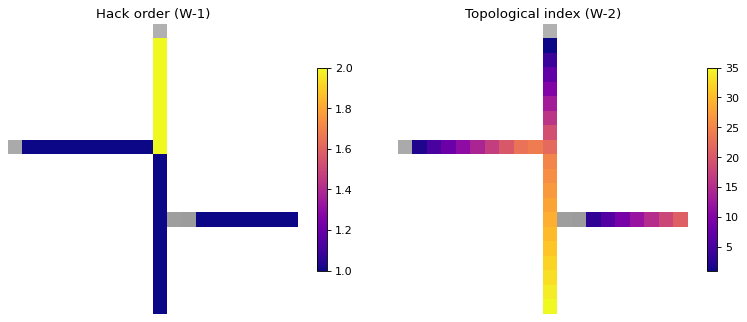

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, arr, title in zip(
    axes, (hack_arr, topo_arr), ("Hack order", "Topological index"),
):
    show = np.where(sm, arr.astype(float), np.nan)
    ax.imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
    im = ax.imshow(show, cmap="plasma", origin="upper")
    ax.set_title(title); ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()
plt.show()


## Per-link sinuosity

`StreamRaster.to_vector(...)` now carries a `sinuosity` column (traced length / straight-line
distance per link). Straight links have sinuosity exactly 1.0; meandering links exceed 1.0.

In [9]:
links = streams.to_vector(fdir, dem=filled)
print(links[["link_id", "length_m", "drop_m", "mean_slope", "sinuosity"]])

   link_id    length_m  drop_m  mean_slope  sinuosity
0        0  240.000000    16.0    0.066667   1.000000
1        1  282.426407    12.0    0.042489   1.039626
2        2  300.000000    20.0    0.066667   1.000000
3        3  180.000000     6.0    0.033333   1.000000


## Main stem

Public API for the longest source-to-outlet path. Returns a binary mask.

In [10]:
main = streams.main_stem(fdir)
print(f"Main-stem cells: {int(main.sum())} of {n_stream} stream cells")
# Verify Hack-order 1 == main_stem mask
assert (hack_arr[main] == 1).all()

Main-stem cells: 20 of 35 stream cells


## Remove short stream links

`prune_short` drops headwater links below `min_length_m`. Internal links (between two confluences)
stay so the network topology is preserved.

In [11]:
pruned = streams.prune_short(fdir, min_length_m=120.0)
n_after = int(pruned.read_array().astype(bool).sum())
print(f"Stream cells before prune: {n_stream}")
print(f"Stream cells after  prune: {n_after}")

Stream cells before prune: 35
Stream cells after  prune: 35


## Visualise: main stem + pre/post-prune comparison

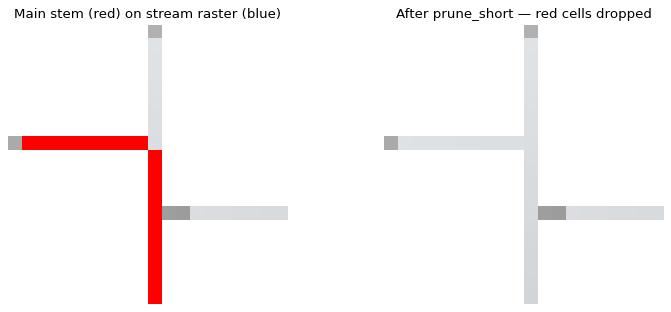

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
axes[0].imshow(np.where(sm, 1, np.nan), cmap="Blues", origin="upper", alpha=0.7)
axes[0].imshow(np.where(main, 1, np.nan), cmap="autumn", origin="upper")
axes[0].set_title("Main stem (red) on stream raster (blue)"); axes[0].axis("off")

after = pruned.read_array().astype(bool)
axes[1].imshow(filled.values, cmap="gray", origin="upper", alpha=0.5)
axes[1].imshow(np.where(sm & ~after, 1, np.nan), cmap="autumn", origin="upper", alpha=0.9)
axes[1].imshow(np.where(after, 1, np.nan), cmap="Blues", origin="upper", alpha=0.7)
axes[1].set_title("After prune_short — red cells dropped"); axes[1].axis("off")
fig.tight_layout()
plt.show()


## Euclidean HAND

Height Above Nearest Drainage using 2D Euclidean distance to the nearest stream cell. Stream cells
are 0; cells far from streams have larger HAND.

In [13]:
hand_eu = filled.hand(streams, method="euclidean")
hand_arr = hand_eu.read_array()
print(f"HAND range on valid cells: [{hand_arr[hand_arr != -9999.0].min():.2f}, "
      f"{hand_arr[hand_arr != -9999.0].max():.2f}] m")
# Stream cells must report HAND = 0
assert (hand_arr[sm] == 0).all()

HAND range on valid cells: [0.00, 98.00] m


## Visualise: Euclidean HAND

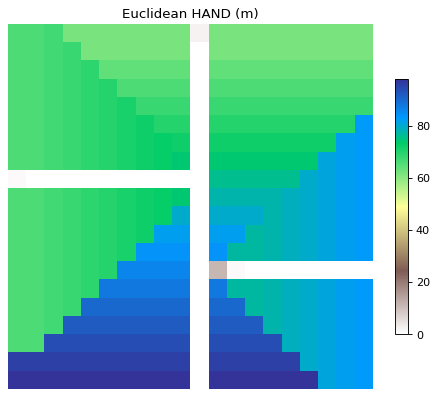

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
show = np.where(hand_arr == -9999.0, np.nan, hand_arr)
im = ax.imshow(show, cmap="terrain_r", origin="upper")
ax.set_title("Euclidean HAND (m)"); ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()
plt.show()


## Summary

From a single 20×20 synthetic DEM we built:
* A complete hydro pipeline via one `full_hydro_pipeline` call.
* Two stream-ordering rasters — Hack and Topological.
* A vector network with sinuosity per link.
* A main-stem binary mask.
* A pruned stream network with short headwater links removed.
* A Euclidean HAND raster.